# S&P 500 Stocks Multivariate Empirical Study

This notebook compares multivariate probability distributions for modeling S&P 500 stock returns.
The main purpose is to test the EM algorithm in real-world high-dimensional settings.

## Distributions Compared

1. **Multivariate Normal** — Baseline Gaussian distribution
2. **Variance Gamma (VG)** — Normal-Gamma mixture, semi-heavy tails
3. **Normal Inverse Gamma (NInvG)** — Normal-InverseGamma mixture, heavy tails
4. **Normal Inverse Gaussian (NIG)** — Normal-InverseGaussian mixture
5. **Generalized Hyperbolic (GH)** — Most general, encompasses VG, NInvG, NIG as special cases

## Methodology

- **Data**: 10 years of S&P 500 constituent stocks daily returns
- **Training**: First 5 years (in-sample)
- **Testing**: Last 5 years (out-of-sample)
- **EM Algorithm**: Track convergence and timing in high dimensions
- **Testing Methods**: Random portfolio projections, KS/AD tests, QQ plots
- **Parameter Analysis**: Compare location (μ) vs skewness (γ) parameters across stocks

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats
from scipy.stats import ks_2samp, anderson_ksamp
import warnings
import time
warnings.filterwarnings('ignore')

from normix import (
    MultivariateNormal,
    VarianceGamma, NormalInverseGamma, NormalInverseGaussian, GeneralizedHyperbolic,
    log_kv,
)

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print("Imports successful!")

Imports successful!


## 1. Load S&P 500 Stock Returns Data

The log returns data is pre-computed and stored in `data/sp500_returns.csv`. 
This file is generated by `scripts/download_sp500_data.py` which fetches S&P 500 constituent stocks from Wikipedia and downloads historical price data from Yahoo Finance.

In [2]:
import os

data_path = '../data/sp500_returns.csv'

if not os.path.exists(data_path):
    raise FileNotFoundError(
        f"Data file not found at {data_path}. "
        "Please run 'python scripts/download_sp500_data.py' first to generate the data."
    )

log_returns = pd.read_csv(data_path, index_col='Date', parse_dates=True)

print(f"Loaded log returns from: {data_path}")
print(f"Shape: {log_returns.shape}")
print(f"Date range: {log_returns.index[0].date()} to {log_returns.index[-1].date()}")
print(f"Number of stocks: {len(log_returns.columns)}")
print(f"First 10 tickers: {list(log_returns.columns[:10])}")

Loaded log returns from: ../data/sp500_returns.csv
Shape: (2552, 468)
Date range: 2015-12-15 to 2026-02-09
Number of stocks: 468
First 10 tickers: ['A', 'AAPL', 'ABBV', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP']


In [3]:
MAX_STOCKS = None

all_tickers = sorted(log_returns.columns.tolist())

if MAX_STOCKS is not None and MAX_STOCKS < len(all_tickers):
    selected_tickers = all_tickers[:MAX_STOCKS]
    print(f"Limited to {MAX_STOCKS} stocks for computational efficiency")
else:
    selected_tickers = all_tickers
    
log_returns_selected = log_returns[selected_tickers]

print(f"Selected {len(selected_tickers)} stocks for analysis:")
print(f"Tickers: {selected_tickers[:20]}{'...' if len(selected_tickers) > 20 else ''}")

Selected 468 stocks for analysis:
Tickers: ['A', 'AAPL', 'ABBV', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB']...


In [4]:
n_total = len(log_returns_selected)
n_train = n_total // 2

train_df = log_returns_selected.iloc[:n_train]
test_df = log_returns_selected.iloc[n_train:]

returns_train = train_df.values
returns_test = test_df.values

print(f"\nTraining period: {train_df.index[0].date()} to {train_df.index[-1].date()}")
print(f"Training samples: {returns_train.shape[0]}, dimensions: {returns_train.shape[1]}")
print(f"\nTesting period: {test_df.index[0].date()} to {test_df.index[-1].date()}")
print(f"Testing samples: {returns_test.shape[0]}, dimensions: {returns_test.shape[1]}")


Training period: 2015-12-15 to 2021-01-08
Training samples: 1276, dimensions: 468

Testing period: 2021-01-11 to 2026-02-09
Testing samples: 1276, dimensions: 468


In [5]:
print("--- Training Data Statistics ---")
mean_returns = returns_train.mean(axis=0) * 100
std_returns = returns_train.std(axis=0) * 100
skewness = stats.skew(returns_train, axis=0)
kurtosis = stats.kurtosis(returns_train, axis=0)

stats_df = pd.DataFrame({
    'Mean (%)': mean_returns,
    'Std (%)': std_returns,
    'Skewness': skewness,
    'Kurtosis': kurtosis
}, index=selected_tickers)

print(stats_df.round(4))

print(f"\n--- Summary ---")
print(f"Average mean return: {mean_returns.mean():.4f}%")
print(f"Average volatility: {std_returns.mean():.4f}%")
print(f"Average skewness: {skewness.mean():.4f}")
print(f"Average excess kurtosis: {kurtosis.mean():.4f}")

--- Training Data Statistics ---
      Mean (%)  Std (%)  Skewness  Kurtosis
A       0.0939   1.6678   -0.6931    7.0987
AAPL    0.1272   1.9018   -0.3579    7.3558
ABBV    0.0690   1.8415   -1.0102   14.7029
ABT     0.0792   1.5958   -0.3926    7.7733
ACGL    0.0351   1.8856   -0.9947   18.7341
...        ...      ...       ...       ...
XYZ     0.2331   3.4473   -1.2234   11.3400
YUM     0.0647   1.5634    1.2150   32.2564
ZBH     0.0401   1.8847   -0.1472   12.3320
ZBRA    0.1391   2.5433   -0.3403    9.4658
ZTS     0.1032   1.5919   -0.3868   13.6900

[468 rows x 4 columns]

--- Summary ---
Average mean return: 0.0585%
Average volatility: 2.0619%
Average skewness: -0.5820
Average excess kurtosis: 17.3627


## 2. Fit Distributions with EM Algorithm Tracking

In [6]:
fitted_dists = {}
fitting_times = {}
em_results = {}

d = returns_train.shape[1]
print(f"Fitting distributions to {d}-dimensional data...")

Fitting distributions to 468-dimensional data...


### 2.1 Multivariate Normal (Baseline)

In [7]:
print("Fitting Multivariate Normal...")
start_time = time.time()

mu_hat = np.mean(returns_train, axis=0)
X_centered = returns_train - mu_hat
sigma_hat = (X_centered.T @ X_centered) / len(returns_train)
mvn = MultivariateNormal.from_classical(mu_hat, sigma_hat)

fitting_times['MVN'] = time.time() - start_time
fitted_dists['MVN'] = mvn

X_train_jnp = jnp.asarray(returns_train, dtype=jnp.float64)
X_test_jnp = jnp.asarray(returns_test, dtype=jnp.float64)

print(f"Fitting time: {fitting_times['MVN']:.2f}s")
print(f"Mean log-likelihood (train): {float(jnp.mean(jax.vmap(mvn.log_prob)(X_train_jnp))):.4f}")
print(f"Mean log-likelihood (test): {float(jnp.mean(jax.vmap(mvn.log_prob)(X_test_jnp))):.4f}")

Fitting Multivariate Normal...
Fitting time: 0.19s
Mean log-likelihood (train): 1482.9039
Mean log-likelihood (test): 1154.9627


### 2.2 Variance Gamma (VG)

In [13]:
print("Fitting Variance Gamma...")
start_time = time.time()

vg_init = VarianceGamma.default_init(returns_train)
vg_result = vg_init.fit(returns_train, max_iter=100, tol=1e-2, verbose=2)
vg = vg_result.model

fitting_times['VG'] = time.time() - start_time
fitted_dists['VG'] = vg
em_results['VG'] = vg_result

print(f"\nFitting time: {fitting_times['VG']:.2f}s")
print(f"Mean log-likelihood (train): {float(vg.marginal_log_likelihood(X_train_jnp)):.4f}")
print(f"Mean log-likelihood (test): {float(vg.marginal_log_likelihood(X_test_jnp)):.4f}")

Fitting Variance Gamma...

  EM Fitting: VarianceGamma
  Loop         : Python loop
  E-step       : cpu
  M-step       : cpu / newton
  Regularize   : none
  Tolerance    : 1.0e-02
  Max iters    : 100
------------------------------------------------------------
  Iter    Log-Lik       ΔLL        |Δparams|   Time
------------------------------------------------------------
     1  1507.251730      ---      5.3070e+08  0.492s
     2  1508.192889  +9.4116e-01  2.1515e-01  0.279s
     3  1508.433126  +2.4024e-01  1.2164e-01  0.257s
     4  1508.491454  +5.8328e-02  6.7346e-02  0.233s
     5  1508.505003  +1.3550e-02  3.5220e-02  0.247s
     6  1508.508068  +3.0646e-03  1.7487e-02  0.241s
     7  1508.508752  +6.8393e-04  8.3865e-03  0.248s
  Converged after 7 iterations (3.07s)
  Final log-likelihood : 1508.508752
  Final |Δparams|      : 8.3865e-03

Fitting time: 3.08s
Mean log-likelihood (train): 1508.5088
Mean log-likelihood (test): 1337.3624


### 2.3 Normal Inverse Gamma (NInvG)

In [10]:
print("Fitting Normal Inverse Gamma...")
start_time = time.time()

ninvg_init = NormalInverseGamma.default_init(returns_train)
ninvg_result = ninvg_init.fit(returns_train, max_iter=100, tol=1e-2, verbose=2)
ninvg = ninvg_result.model

fitting_times['NInvG'] = time.time() - start_time
fitted_dists['NInvG'] = ninvg
em_results['NInvG'] = ninvg_result

print(f"\nFitting time: {fitting_times['NInvG']:.2f}s")
print(f"Mean log-likelihood (train): {float(ninvg.marginal_log_likelihood(X_train_jnp)):.4f}")
print(f"Mean log-likelihood (test): {float(ninvg.marginal_log_likelihood(X_test_jnp)):.4f}")

Fitting Normal Inverse Gamma...

  EM Fitting: NormalInverseGamma
  Loop         : Python loop
  E-step       : cpu
  M-step       : cpu / newton
  Regularize   : none
  Tolerance    : 1.0e-02
  Max iters    : 100
------------------------------------------------------------
  Iter    Log-Lik       ΔLL        |Δparams|   Time
------------------------------------------------------------
     1  1507.337904      ---      5.4209e+08  0.516s
     2  1508.384656  +1.0468e+00  2.2842e-01  0.232s
     3  1508.639040  +2.5438e-01  1.3906e-01  0.233s
     4  1508.695206  +5.6166e-02  8.0225e-02  0.230s
     5  1508.706870  +1.1664e-02  3.6340e-02  0.233s
     6  1508.708976  +2.1065e-03  1.8487e-02  0.243s
     7  1508.709593  +6.1699e-04  8.6068e-03  0.233s
  Converged after 7 iterations (2.95s)
  Final log-likelihood : 1508.709593
  Final |Δparams|      : 8.6068e-03

Fitting time: 3.00s
Mean log-likelihood (train): 1508.7096
Mean log-likelihood (test): 1337.4737


### 2.4 Normal Inverse Gaussian (NIG)

In [11]:
print("Fitting Normal Inverse Gaussian...")
start_time = time.time()

nig_init = NormalInverseGaussian.default_init(returns_train)
nig_result = nig_init.fit(returns_train, max_iter=100, tol=1e-2, verbose=2)
nig = nig_result.model

fitting_times['NIG'] = time.time() - start_time
fitted_dists['NIG'] = nig
em_results['NIG'] = nig_result

print(f"\nFitting time: {fitting_times['NIG']:.2f}s")
print(f"Mean log-likelihood (train): {float(nig.marginal_log_likelihood(X_train_jnp)):.4f}")
print(f"Mean log-likelihood (test): {float(nig.marginal_log_likelihood(X_test_jnp)):.4f}")

Fitting Normal Inverse Gaussian...

  EM Fitting: NormalInverseGaussian
  Loop         : Python loop
  E-step       : jax
  M-step       : cpu / newton
  Regularize   : none
  Tolerance    : 1.0e-02
  Max iters    : 100
------------------------------------------------------------
  Iter    Log-Lik       ΔLL        |Δparams|   Time
------------------------------------------------------------
     1  1507.320511      ---      5.3639e+08  3.820s
     2  1508.322342  +1.0018e+00  2.2211e-01  0.358s
     3  1508.572311  +2.4997e-01  1.3001e-01  0.381s
     4  1508.630343  +5.8032e-02  7.2651e-02  0.793s
     5  1508.643065  +1.2722e-02  3.7583e-02  0.433s
     6  1508.645766  +2.7010e-03  1.8224e-02  0.406s
     7  1508.646331  +5.6518e-04  8.4823e-03  0.383s
  Converged after 7 iterations (8.17s)
  Final log-likelihood : 1508.646331
  Final |Δparams|      : 8.4823e-03

Fitting time: 8.18s
Mean log-likelihood (train): 1508.6463
Mean log-likelihood (test): 1337.5151


### 2.5 Generalized Hyperbolic (GH)

In [12]:
print("Fitting Generalized Hyperbolic...")
print("This is the most general model and may take longer...")
start_time = time.time()

gh_init = GeneralizedHyperbolic.default_init(returns_train)
gh_result = gh_init.fit(returns_train, max_iter=100, tol=1e-2, verbose=2, m_step_method='lbfgs')
gh = gh_result.model

fitting_times['GH'] = time.time() - start_time
fitted_dists['GH'] = gh
em_results['GH'] = gh_result

print(f"\nFitting time: {fitting_times['GH']:.2f}s")
print(f"Mean log-likelihood (train): {float(gh.marginal_log_likelihood(X_train_jnp)):.4f}")
print(f"Mean log-likelihood (test): {float(gh.marginal_log_likelihood(X_test_jnp)):.4f}")

Fitting Generalized Hyperbolic...
This is the most general model and may take longer...

  EM Fitting: GeneralizedHyperbolic
  Loop         : Python loop
  E-step       : cpu
  M-step       : cpu / lbfgs
  Regularize   : det_sigma_one
  Tolerance    : 1.0e-02
  Max iters    : 100
------------------------------------------------------------
  Iter    Log-Lik       ΔLL        |Δparams|   Time
------------------------------------------------------------
     1  1508.708929      ---      4.7287e+03  0.465s
     2  1508.709539  +6.1018e-04  8.4718e-03  0.057s
  Converged after 2 iterations (1.84s)
  Final log-likelihood : 1508.709539
  Final |Δparams|      : 8.4718e-03

Fitting time: 6.99s
Mean log-likelihood (train): 1508.7095
Mean log-likelihood (test): 1337.4538


## 3. Summary of Fitting Results

In [14]:
results = []

for name, dist in fitted_dists.items():
    if name == 'MVN':
        train_ll = float(jnp.mean(jax.vmap(dist.log_prob)(X_train_jnp)))
        test_ll = float(jnp.mean(jax.vmap(dist.log_prob)(X_test_jnp)))
    else:
        train_ll = float(dist.marginal_log_likelihood(X_train_jnp))
        test_ll = float(dist.marginal_log_likelihood(X_test_jnp))
    
    results.append({
        'Distribution': name,
        'Train LL': train_ll,
        'Test LL': test_ll,
        'Fitting Time (s)': fitting_times[name]
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test LL', ascending=False)

print("\n" + "="*70)
print("SUMMARY: Distribution Fitting Results")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)


SUMMARY: Distribution Fitting Results
Distribution    Train LL     Test LL  Fitting Time (s)
         NIG 1508.646331 1337.515051          8.182107
       NInvG 1508.709593 1337.473653          2.995856
          GH 1508.709539 1337.453759          6.988197
          VG 1508.508752 1337.362438          3.081542
         MVN 1482.903909 1154.962654          0.193952


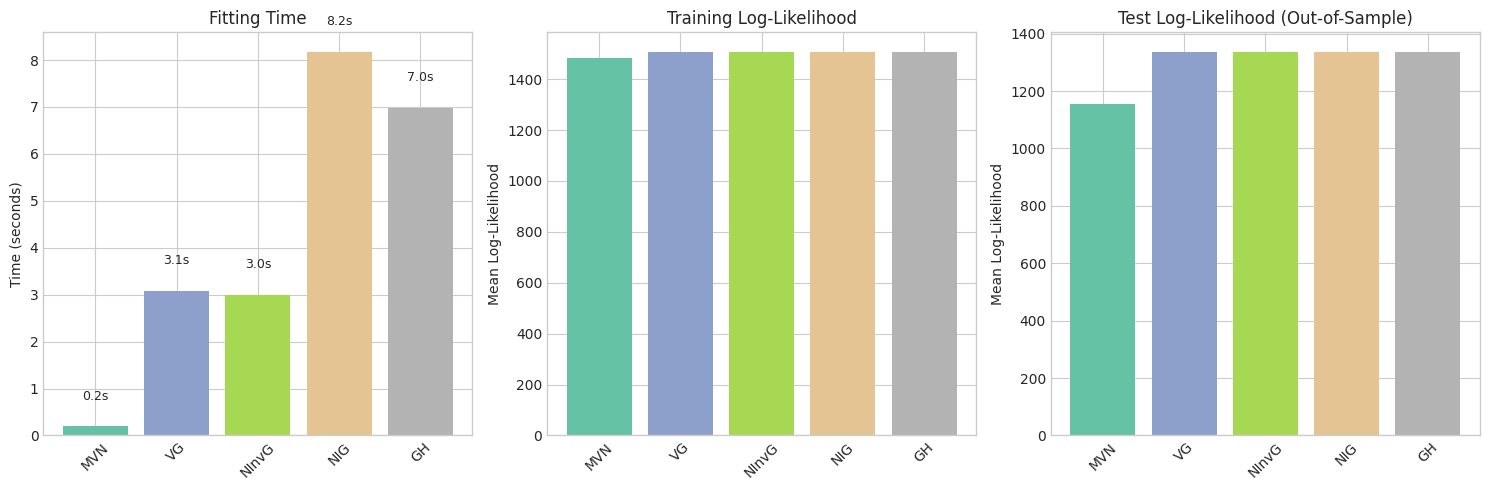

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

dist_names = list(fitted_dists.keys())
colors = plt.cm.Set2(np.linspace(0, 1, len(dist_names)))

ax1 = axes[0]
times = [fitting_times[n] for n in dist_names]
bars1 = ax1.bar(dist_names, times, color=colors)
ax1.set_ylabel('Time (seconds)')
ax1.set_title('Fitting Time')
ax1.tick_params(axis='x', rotation=45)
for bar, t in zip(bars1, times):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{t:.1f}s', ha='center', va='bottom', fontsize=9)

ax2 = axes[1]
train_lls = []
for n in dist_names:
    dist = fitted_dists[n]
    if n == 'MVN':
        train_lls.append(float(jnp.mean(jax.vmap(dist.log_prob)(X_train_jnp))))
    else:
        train_lls.append(float(dist.marginal_log_likelihood(X_train_jnp)))
bars2 = ax2.bar(dist_names, train_lls, color=colors)
ax2.set_ylabel('Mean Log-Likelihood')
ax2.set_title('Training Log-Likelihood')
ax2.tick_params(axis='x', rotation=45)

ax3 = axes[2]
test_lls = []
for n in dist_names:
    dist = fitted_dists[n]
    if n == 'MVN':
        test_lls.append(float(jnp.mean(jax.vmap(dist.log_prob)(X_test_jnp))))
    else:
        test_lls.append(float(dist.marginal_log_likelihood(X_test_jnp)))
bars3 = ax3.bar(dist_names, test_lls, color=colors)
ax3.set_ylabel('Mean Log-Likelihood')
ax3.set_title('Test Log-Likelihood (Out-of-Sample)')
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Random Portfolio Projections Testing

In [16]:
def generate_random_weights(d, n_portfolios=100, random_state=None):
    """Generate random portfolio weights from Dirichlet (positive, sum to 1)."""
    rng = np.random.default_rng(random_state)
    return rng.dirichlet(np.ones(d), size=n_portfolios)


def project_returns(returns, weights):
    """Project multivariate returns to 1D portfolio returns."""
    if weights.ndim == 1:
        return returns @ weights
    else:
        return returns @ weights.T

In [17]:
N_PORTFOLIOS = 100
random_weights = generate_random_weights(d, n_portfolios=N_PORTFOLIOS, random_state=42)

print(f"Generated {N_PORTFOLIOS} random portfolios")
print(f"Weight matrix shape: {random_weights.shape}")
print(f"First portfolio weights: {random_weights[0][:5].round(3)}...")

Generated 100 random portfolios
Weight matrix shape: (100, 468)
First portfolio weights: [0.005 0.005 0.005 0.001 0.   ]...


In [18]:
def portfolio_test(dist, dist_name, returns_test, weights, n_samples=10000, seed=None):
    """Test a distribution using random portfolio projections."""
    if dist_name == 'MVN':
        key = jax.random.PRNGKey(seed or 42)
        samples = np.asarray(dist.sample(key, shape=(n_samples,)))
    else:
        samples = dist.rvs(n_samples, seed=seed or 42)
    
    n_portfolios = weights.shape[0]
    ks_stats = []
    ks_pvals = []
    ad_stats = []
    
    for i in range(n_portfolios):
        w = weights[i]
        test_proj = returns_test @ w
        sample_proj = samples @ w
        
        ks_stat, ks_pval = ks_2samp(test_proj, sample_proj)
        ks_stats.append(ks_stat)
        ks_pvals.append(ks_pval)
        
        try:
            ad_result = anderson_ksamp([test_proj, sample_proj])
            ad_stats.append(ad_result.statistic)
        except Exception:
            ad_stats.append(np.nan)
    
    return {
        'ks_stats': np.array(ks_stats),
        'ks_pvals': np.array(ks_pvals),
        'ad_stats': np.array(ad_stats),
        'ks_mean': np.mean(ks_stats),
        'ks_median': np.median(ks_stats),
        'ad_mean': np.nanmean(ad_stats),
        'ad_median': np.nanmedian(ad_stats),
        'ks_reject_rate': np.mean(np.array(ks_pvals) < 0.05)
    }

In [19]:
portfolio_results = {}

print("Running portfolio projection tests...")
print(f"Testing with {N_PORTFOLIOS} random portfolios\n")

for name, dist in fitted_dists.items():
    print(f"Testing {name}...")
    try:
        results = portfolio_test(dist, name, returns_test, random_weights,
                                 n_samples=5000, seed=42)
        portfolio_results[name] = results
        print(f"  KS mean: {results['ks_mean']:.4f}, KS reject rate: {results['ks_reject_rate']:.2%}")
        print(f"  AD mean: {results['ad_mean']:.4f}")
    except Exception as e:
        print(f"  Error: {e}")
        portfolio_results[name] = None

Running portfolio projection tests...
Testing with 100 random portfolios

Testing MVN...
  KS mean: 0.1014, KS reject rate: 100.00%
  AD mean: 35.8250
Testing VG...
  KS mean: 0.0325, KS reject rate: 0.00%
  AD mean: 0.9408
Testing NInvG...
  KS mean: 0.0335, KS reject rate: 0.00%
  AD mean: 0.2787
Testing NIG...
  KS mean: 0.0359, KS reject rate: 3.00%
  AD mean: 0.9279
Testing GH...
  KS mean: 0.0352, KS reject rate: 2.00%
  AD mean: 0.5118


In [20]:
test_summary = []
for name, results in portfolio_results.items():
    if results is not None:
        test_summary.append({
            'Distribution': name,
            'KS Mean': results['ks_mean'],
            'KS Median': results['ks_median'],
            'KS Reject Rate': results['ks_reject_rate'],
            'AD Mean': results['ad_mean'],
            'AD Median': results['ad_median']
        })

test_df = pd.DataFrame(test_summary)
test_df = test_df.sort_values('KS Mean')

print("\n" + "="*80)
print("PORTFOLIO PROJECTION TEST RESULTS")
print("Lower KS/AD statistics indicate better fit")
print("="*80)
print(test_df.to_string(index=False))
print("="*80)


PORTFOLIO PROJECTION TEST RESULTS
Lower KS/AD statistics indicate better fit
Distribution  KS Mean  KS Median  KS Reject Rate   AD Mean  AD Median
          VG 0.032498   0.032229            0.00  0.940816   0.928666
       NInvG 0.033478   0.033133            0.00  0.278652   0.285310
          GH 0.035243   0.035098            0.02  0.511781   0.498879
         NIG 0.035943   0.035817            0.03  0.927942   0.952975
         MVN 0.101447   0.101050            1.00 35.824953  35.794776


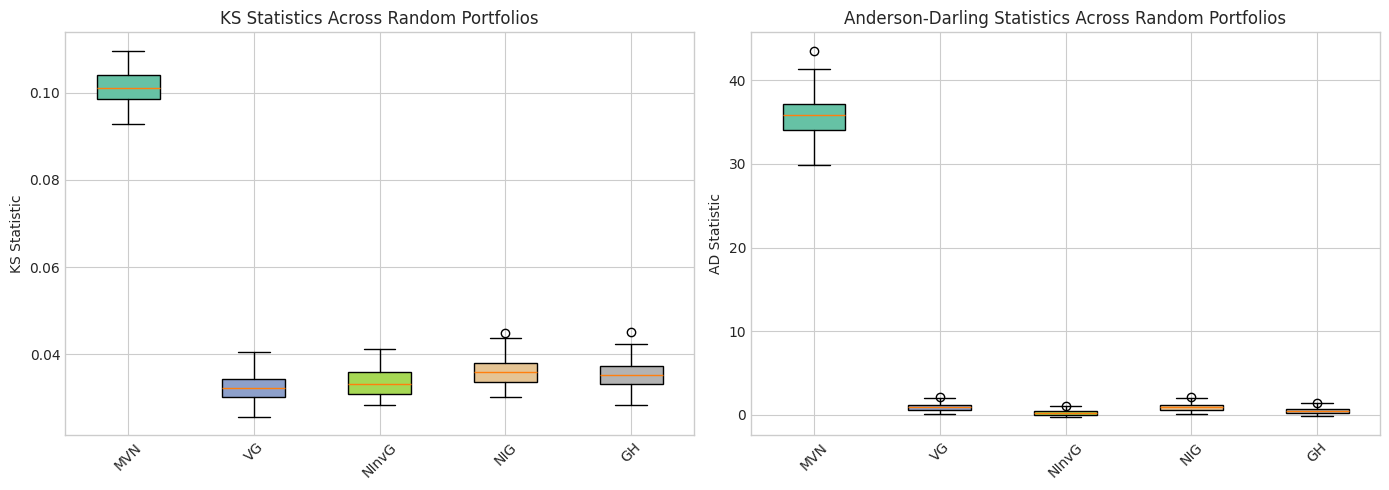

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ks_data = [portfolio_results[n]['ks_stats'] for n in fitted_dists.keys() if portfolio_results[n] is not None]
ks_labels = [n for n in fitted_dists.keys() if portfolio_results[n] is not None]
bp1 = ax1.boxplot(ks_data, labels=ks_labels, patch_artist=True)
for patch, color in zip(bp1['boxes'], colors[:len(ks_labels)]):
    patch.set_facecolor(color)
ax1.set_ylabel('KS Statistic')
ax1.set_title('KS Statistics Across Random Portfolios')
ax1.tick_params(axis='x', rotation=45)

ax2 = axes[1]
ad_data = [portfolio_results[n]['ad_stats'] for n in fitted_dists.keys() if portfolio_results[n] is not None]
ad_labels = [n for n in fitted_dists.keys() if portfolio_results[n] is not None]
bp2 = ax2.boxplot(ad_data, labels=ad_labels, patch_artist=True)
for patch, color in zip(bp2['boxes'], colors[:len(ad_labels)]):
    patch.set_facecolor(color)
ax2.set_ylabel('AD Statistic')
ax2.set_title('Anderson-Darling Statistics Across Random Portfolios')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Quantile Range Plots

In [22]:
def compute_quantile_comparison(dist, dist_name, returns_test, weights,
                                 quantiles=np.linspace(0.01, 0.99, 99),
                                 n_samples=10000, seed=None):
    """Compute quantile comparison for multiple portfolios."""
    if dist_name == 'MVN':
        key = jax.random.PRNGKey(seed or 42)
        samples = np.asarray(dist.sample(key, shape=(n_samples,)))
    else:
        samples = dist.rvs(n_samples, seed=seed or 42)
    
    n_portfolios = weights.shape[0]
    n_quantiles = len(quantiles)
    
    empirical_quantiles = np.zeros((n_portfolios, n_quantiles))
    theoretical_quantiles = np.zeros((n_portfolios, n_quantiles))
    
    for i in range(n_portfolios):
        w = weights[i]
        test_proj = returns_test @ w
        sample_proj = samples @ w
        
        empirical_quantiles[i] = np.quantile(test_proj, quantiles)
        theoretical_quantiles[i] = np.quantile(sample_proj, quantiles)
    
    return empirical_quantiles, theoretical_quantiles, quantiles

In [23]:
quantile_results = {}
quantiles = np.linspace(0.01, 0.99, 99)

for name, dist in fitted_dists.items():
    print(f"Computing quantiles for {name}...")
    try:
        emp_q, theo_q, q = compute_quantile_comparison(
            dist, name, returns_test, random_weights,
            quantiles=quantiles, n_samples=10000, seed=42
        )
        quantile_results[name] = (emp_q, theo_q, q)
    except Exception as e:
        print(f"  Error: {e}")

Computing quantiles for MVN...
Computing quantiles for VG...
Computing quantiles for NInvG...
Computing quantiles for NIG...
Computing quantiles for GH...


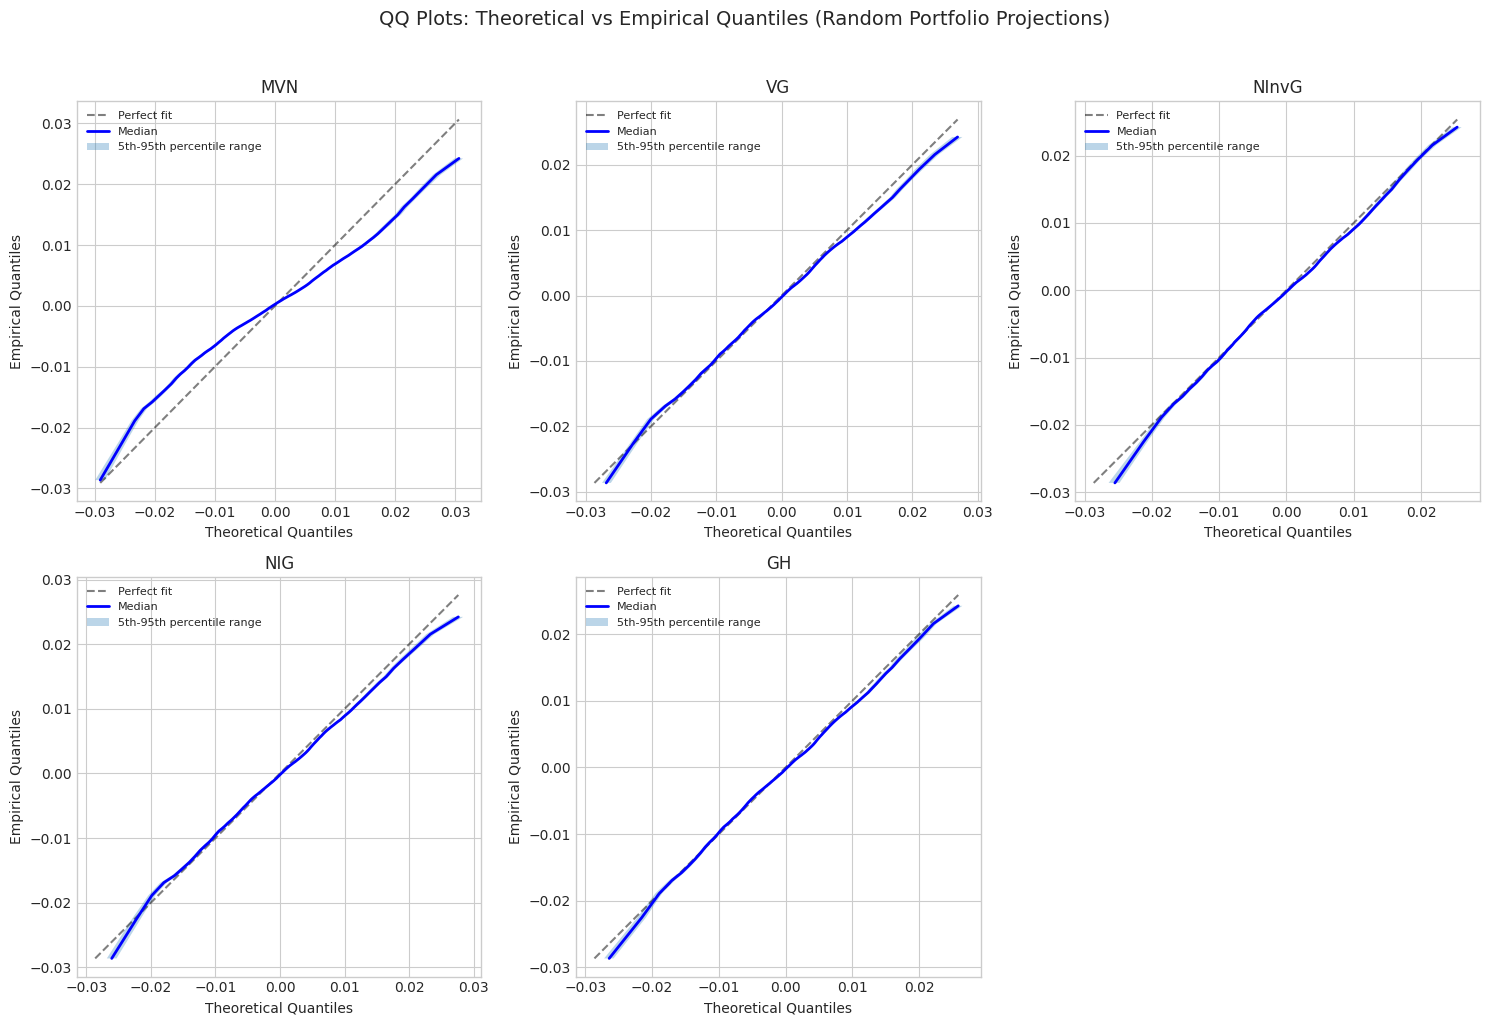

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, (emp_q, theo_q, q)) in enumerate(quantile_results.items()):
    if idx >= len(axes):
        break
    ax = axes[idx]
    
    emp_median = np.median(emp_q, axis=0)
    emp_lower = np.percentile(emp_q, 5, axis=0)
    emp_upper = np.percentile(emp_q, 95, axis=0)
    
    theo_median = np.median(theo_q, axis=0)
    theo_lower = np.percentile(theo_q, 5, axis=0)
    theo_upper = np.percentile(theo_q, 95, axis=0)
    
    min_val = min(emp_median.min(), theo_median.min())
    max_val = max(emp_median.max(), theo_median.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Perfect fit')
    
    ax.plot(theo_median, emp_median, 'b-', lw=2, label='Median')
    ax.fill_betweenx(emp_median, theo_lower, theo_upper, alpha=0.3,
                     label='5th-95th percentile range')
    
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Empirical Quantiles')
    ax.set_title(f'{name}')
    ax.legend(loc='upper left', fontsize=8)

for idx in range(len(quantile_results), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('QQ Plots: Theoretical vs Empirical Quantiles (Random Portfolio Projections)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Parameter Analysis: Location (μ) vs Skewness (γ)

In [25]:
def extract_mixture_params(dist, name):
    """
    Extract μ, γ, σ (diagonal of Σ), and E[Y] from fitted distributions.
    Uses the normix JAX API: model.joint for accessing underlying parameters,
    model.joint.subordinator() for mixing distribution moments.
    """
    if name == 'MVN':
        mu = np.asarray(dist.mu)
        sigma_diag = np.sqrt(np.diag(np.asarray(dist.sigma)))
        gamma = np.zeros_like(mu)
        E_Y = 1.0
        Var_Y = 0.0
        return mu, gamma, sigma_diag, E_Y, Var_Y, None
    else:
        j = dist.joint
        sub = j.subordinator()
        mu = np.asarray(j.mu)
        gamma = np.asarray(j.gamma)
        sigma_diag = np.sqrt(np.diag(np.asarray(dist.cov())))
        E_Y = float(sub.mean())
        Var_Y = float(sub.var())
        
        mix_params = {}
        if name == 'VG':
            mix_params = {'alpha': float(j.alpha), 'beta': float(j.beta)}
        elif name == 'NInvG':
            mix_params = {'alpha': float(j.alpha), 'beta': float(j.beta)}
        elif name == 'NIG':
            mix_params = {'mu_ig': float(j.mu_ig), 'lam': float(j.lam)}
        elif name == 'GH':
            mix_params = {'p': float(j.p), 'a': float(j.a), 'b': float(j.b)}
        
        return mu, gamma, sigma_diag, E_Y, Var_Y, mix_params


param_data = {}
for name, dist in fitted_dists.items():
    try:
        mu, gamma, sigma, E_Y, Var_Y, mix_params = extract_mixture_params(dist, name)
        param_data[name] = {
            'mu': mu,
            'gamma': gamma,
            'sigma': sigma,
            'E_Y': E_Y,
            'Var_Y': Var_Y,
            'mu_over_sigma': mu / sigma,
            'gamma_over_sigma': gamma / sigma,
            'gamma_E_Y_over_sigma': gamma * E_Y / sigma,
            'mix_params': mix_params
        }
        print(f"{name}: μ range [{mu.min():.6f}, {mu.max():.6f}], γ range [{gamma.min():.6f}, {gamma.max():.6f}], E[Y] = {E_Y:.6f}")
        print(f"       γ*E[Y] range [{(gamma*E_Y).min():.6f}, {(gamma*E_Y).max():.6f}]")
    except Exception as e:
        print(f"Error extracting params for {name}: {e}")

MVN: μ range [-0.001088, 0.002899], γ range [0.000000, 0.000000], E[Y] = 1.000000
       γ*E[Y] range [0.000000, 0.000000]
VG: μ range [-0.001245, 0.004995], γ range [-0.005790, 0.002366], E[Y] = 0.568577
       γ*E[Y] range [-0.003292, 0.001345]
NInvG: μ range [-0.001237, 0.004980], γ range [-0.005594, 0.002243], E[Y] = 0.554012
       γ*E[Y] range [-0.003099, 0.001243]
NIG: μ range [-0.001240, 0.004985], γ range [-0.005675, 0.002299], E[Y] = 0.571749
       γ*E[Y] range [-0.003244, 0.001314]
GH: μ range [-0.001237, 0.004981], γ range [-26.930414, 10.798645], E[Y] = 0.000115
       γ*E[Y] range [-0.003089, 0.001239]


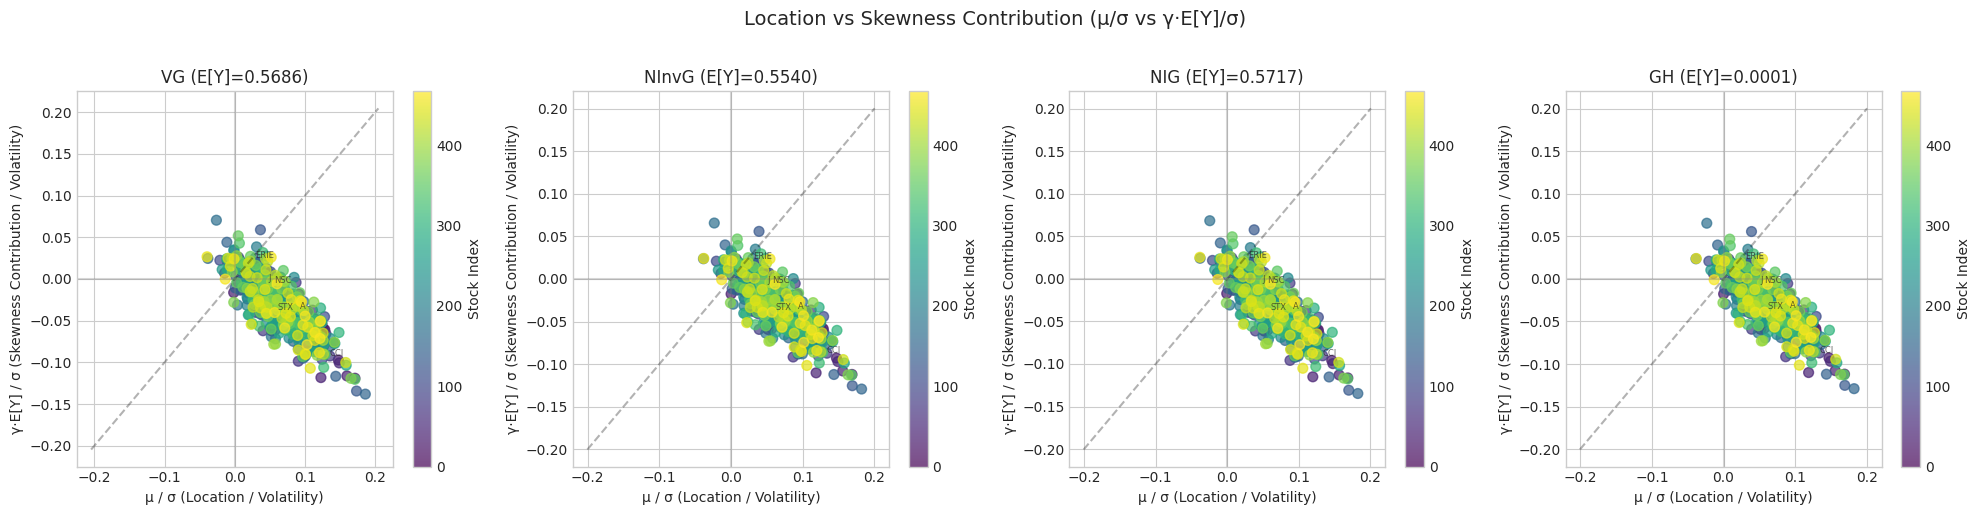

In [26]:
mixture_dists = [n for n in ['VG', 'NInvG', 'NIG', 'GH'] if n in param_data]

if mixture_dists:
    n_plots = len(mixture_dists)
    fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 5))
    if n_plots == 1:
        axes = [axes]
    
    for idx, name in enumerate(mixture_dists):
        ax = axes[idx]
        data = param_data[name]
        
        mu_norm = data['mu_over_sigma']
        gamma_E_Y_norm = data['gamma_E_Y_over_sigma']
        
        scatter = ax.scatter(mu_norm, gamma_E_Y_norm, c=range(len(mu_norm)),
                            cmap='viridis', s=50, alpha=0.7)
        
        lim = max(abs(mu_norm).max(), abs(gamma_E_Y_norm).max()) * 1.1
        if np.isfinite(lim) and lim > 0:
            ax.plot([-lim, lim], [-lim, lim], 'k--', alpha=0.3, label='μ = γE[Y]')
        ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
        ax.axvline(0, color='gray', linestyle='-', alpha=0.3)
        
        ax.set_xlabel('μ / σ (Location / Volatility)')
        ax.set_ylabel('γ·E[Y] / σ (Skewness Contribution / Volatility)')
        ax.set_title(f'{name} (E[Y]={data["E_Y"]:.4f})')
        
        plt.colorbar(scatter, ax=ax, label='Stock Index')
        
        n_labels = min(len(selected_tickers), 6)
        step = max(1, len(selected_tickers) // n_labels)
        for i, ticker in enumerate(selected_tickers):
            if i % step == 0:
                ax.annotate(ticker, (mu_norm[i], gamma_E_Y_norm[i]), fontsize=6, alpha=0.7)
    
    plt.suptitle('Location vs Skewness Contribution (μ/σ vs γ·E[Y]/σ)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

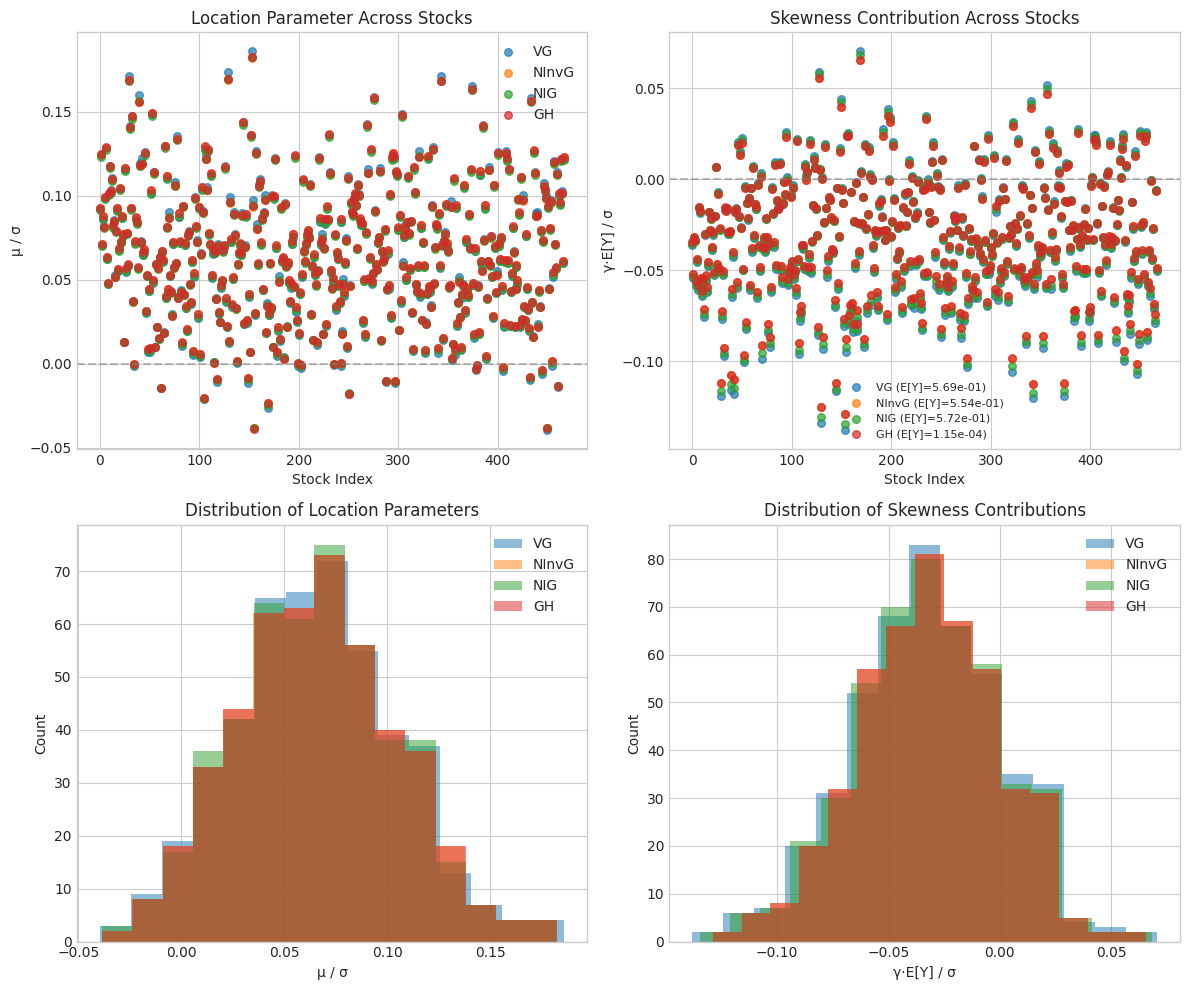

In [27]:
if len(mixture_dists) >= 2:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    ax1 = axes[0, 0]
    for name in mixture_dists:
        data = param_data[name]
        ax1.scatter(range(len(data['mu_over_sigma'])), data['mu_over_sigma'],
                   label=name, alpha=0.7, s=30)
    ax1.set_xlabel('Stock Index')
    ax1.set_ylabel('μ / σ')
    ax1.set_title('Location Parameter Across Stocks')
    ax1.legend()
    ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
    
    ax2 = axes[0, 1]
    for name in mixture_dists:
        data = param_data[name]
        ax2.scatter(range(len(data['gamma_E_Y_over_sigma'])), data['gamma_E_Y_over_sigma'],
                   label=f"{name} (E[Y]={data['E_Y']:.2e})", alpha=0.7, s=30)
    ax2.set_xlabel('Stock Index')
    ax2.set_ylabel('γ·E[Y] / σ')
    ax2.set_title('Skewness Contribution Across Stocks')
    ax2.legend(fontsize=8)
    ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
    
    ax3 = axes[1, 0]
    for name in mixture_dists:
        data = param_data[name]
        ax3.hist(data['mu_over_sigma'], bins=15, alpha=0.5, label=name)
    ax3.set_xlabel('μ / σ')
    ax3.set_ylabel('Count')
    ax3.set_title('Distribution of Location Parameters')
    ax3.legend()
    
    ax4 = axes[1, 1]
    for name in mixture_dists:
        data = param_data[name]
        ax4.hist(data['gamma_E_Y_over_sigma'], bins=15, alpha=0.5, label=name)
    ax4.set_xlabel('γ·E[Y] / σ')
    ax4.set_ylabel('Count')
    ax4.set_title('Distribution of Skewness Contributions')
    ax4.legend()
    
    plt.tight_layout()
    plt.show()

MOMENT COMPARISON FROM ESTIMATED DISTRIBUTIONS

VG:
  E[Y] = 5.685765e-01, Var[Y] = 1.476054e-01
  Mean: Dist avg = 5.845287e-04, Empirical avg = 5.845287e-04
         MAE = 1.745250e-19
  Var:  Dist avg = 3.865571e-04, Empirical avg = 4.551968e-04
         MAE = 8.282682e-05

NInvG:
  E[Y] = 5.540123e-01, Var[Y] = 2.939201e-01
  Mean: Dist avg = 6.046296e-04, Empirical avg = 5.845287e-04
         MAE = 2.375779e-05
  Var:  Dist avg = 3.784427e-04, Empirical avg = 4.551968e-04
         MAE = 8.788150e-05

NIG:
  E[Y] = 5.717486e-01, Var[Y] = 1.747389e-01
  Mean: Dist avg = 5.845287e-04, Empirical avg = 5.845287e-04
         MAE = 1.783041e-19
  Var:  Dist avg = 3.893869e-04, Empirical avg = 4.551968e-04
         MAE = 8.157630e-05

GH:
  E[Y] = 1.147010e-04, Var[Y] = 1.282606e-08
  Mean: Dist avg = 6.064972e-04, Empirical avg = 5.845287e-04
         MAE = 2.596329e-05
  Var:  Dist avg = 3.771773e-04, Empirical avg = 4.551968e-04
         MAE = 8.867239e-05


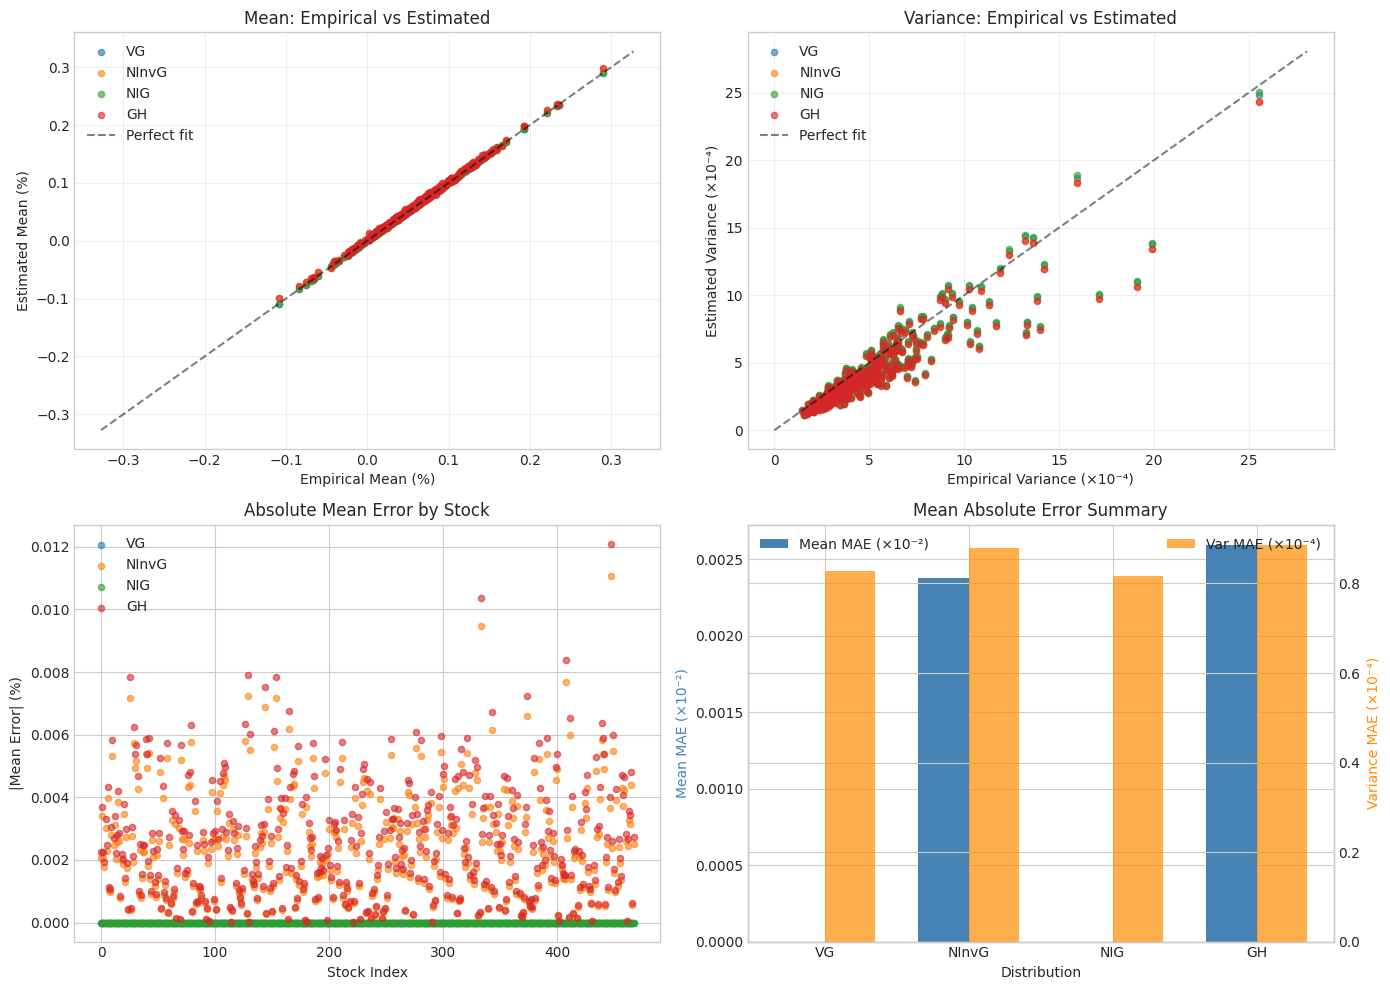


SUMMARY TABLE: Distribution Moment Comparison
Distribution     E[Y]       Var[Y]     Mean MAE  Var MAE
          VG 0.568577 1.476054e-01 1.745250e-19 0.000083
       NInvG 0.554012 2.939201e-01 2.375779e-05 0.000088
         NIG 0.571749 1.747389e-01 1.783041e-19 0.000082
          GH 0.000115 1.282606e-08 2.596329e-05 0.000089


In [28]:
# Moment comparison: empirical vs distribution-implied
# For X = μ + γY + √Y·ε: E[X] = μ + γE[Y], Var[X]_i = E[Y]·Σ_ii + Var[Y]·γ_i²

print("="*80)
print("MOMENT COMPARISON FROM ESTIMATED DISTRIBUTIONS")
print("="*80)

empirical_mean = returns_train.mean(axis=0)
empirical_var = returns_train.var(axis=0)

moment_comparison = {}

for name in mixture_dists:
    data = param_data[name]
    mu = data['mu']
    gamma = data['gamma']
    E_Y = data['E_Y']
    Var_Y = data['Var_Y']
    
    j = fitted_dists[name].joint
    sigma_diag_sq = np.diag(np.asarray(j.sigma()))
    
    dist_mean = mu + gamma * E_Y
    dist_var = E_Y * sigma_diag_sq + Var_Y * (gamma ** 2)
    
    moment_comparison[name] = {
        'E_Y': E_Y,
        'Var_Y': Var_Y,
        'dist_mean': dist_mean,
        'dist_var': dist_var,
        'dist_std': np.sqrt(np.abs(dist_var)),
        'mean_error': np.mean(np.abs(dist_mean - empirical_mean)),
        'var_error': np.mean(np.abs(dist_var - empirical_var))
    }
    
    print(f"\n{name}:")
    print(f"  E[Y] = {E_Y:.6e}, Var[Y] = {Var_Y:.6e}")
    print(f"  Mean: Dist avg = {dist_mean.mean():.6e}, Empirical avg = {empirical_mean.mean():.6e}")
    print(f"         MAE = {moment_comparison[name]['mean_error']:.6e}")
    print(f"  Var:  Dist avg = {dist_var.mean():.6e}, Empirical avg = {empirical_var.mean():.6e}")
    print(f"         MAE = {moment_comparison[name]['var_error']:.6e}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
for name in mixture_dists:
    mc = moment_comparison[name]
    ax1.scatter(empirical_mean * 100, mc['dist_mean'] * 100, label=name, alpha=0.6, s=20)
lim = max(abs(empirical_mean).max(), max(abs(mc['dist_mean']).max() for mc in moment_comparison.values())) * 100 * 1.1
ax1.plot([-lim, lim], [-lim, lim], 'k--', alpha=0.5, label='Perfect fit')
ax1.set_xlabel('Empirical Mean (%)')
ax1.set_ylabel('Estimated Mean (%)')
ax1.set_title('Mean: Empirical vs Estimated')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
for name in mixture_dists:
    mc = moment_comparison[name]
    ax2.scatter(empirical_var * 10000, mc['dist_var'] * 10000, label=name, alpha=0.6, s=20)
lim = max(empirical_var.max(), max(mc['dist_var'].max() for mc in moment_comparison.values() if np.isfinite(mc['dist_var']).all())) * 10000 * 1.1
ax2.plot([0, lim], [0, lim], 'k--', alpha=0.5, label='Perfect fit')
ax2.set_xlabel('Empirical Variance (×10⁻⁴)')
ax2.set_ylabel('Estimated Variance (×10⁻⁴)')
ax2.set_title('Variance: Empirical vs Estimated')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
for name in mixture_dists:
    mc = moment_comparison[name]
    mean_errors = np.abs(mc['dist_mean'] - empirical_mean) * 100
    ax3.scatter(range(len(mean_errors)), mean_errors, label=name, alpha=0.6, s=20)
ax3.set_xlabel('Stock Index')
ax3.set_ylabel('|Mean Error| (%)')
ax3.set_title('Absolute Mean Error by Stock')
ax3.legend()

ax4 = axes[1, 1]
names = list(moment_comparison.keys())
mean_maes = [moment_comparison[n]['mean_error'] * 100 for n in names]
var_maes = [moment_comparison[n]['var_error'] * 10000 for n in names]

x = np.arange(len(names))
width = 0.35
bars1 = ax4.bar(x - width/2, mean_maes, width, label='Mean MAE (×10⁻²)', color='steelblue')
ax4_twin = ax4.twinx()
bars2 = ax4_twin.bar(x + width/2, var_maes, width, label='Var MAE (×10⁻⁴)', color='darkorange', alpha=0.7)

ax4.set_xlabel('Distribution')
ax4.set_ylabel('Mean MAE (×10⁻²)', color='steelblue')
ax4_twin.set_ylabel('Variance MAE (×10⁻⁴)', color='darkorange')
ax4.set_xticks(x)
ax4.set_xticklabels(names)
ax4.set_title('Mean Absolute Error Summary')
ax4.legend(loc='upper left')
ax4_twin.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("SUMMARY TABLE: Distribution Moment Comparison")
print("="*80)
summary_df = pd.DataFrame({
    'Distribution': names,
    'E[Y]': [moment_comparison[n]['E_Y'] for n in names],
    'Var[Y]': [moment_comparison[n]['Var_Y'] for n in names],
    'Mean MAE': [moment_comparison[n]['mean_error'] for n in names],
    'Var MAE': [moment_comparison[n]['var_error'] for n in names]
})
print(summary_df.to_string(index=False))

In [29]:
best_dist = 'GH' if 'GH' in param_data else list(param_data.keys())[-1]

if best_dist in param_data:
    data = param_data[best_dist]
    
    param_table = pd.DataFrame({
        'Ticker': selected_tickers,
        'μ': data['mu'],
        'γ': data['gamma'],
        'γ·E[Y]': data['gamma'] * data['E_Y'],
        'σ': data['sigma'],
        'μ/σ': data['mu_over_sigma'],
        'γ/σ': data['gamma_over_sigma'],
        'γ·E[Y]/σ': data['gamma_E_Y_over_sigma']
    })
    
    param_table_sorted = param_table.sort_values('γ·E[Y]/σ')
    
    print(f"\n{best_dist} Parameters by Stock (sorted by skewness contribution γ·E[Y]/σ):")
    print(f"Note: E[Y] = {data['E_Y']:.6e}")
    print("="*100)
    print(param_table_sorted.to_string(index=False))
    print("="*100)
    
    if data['mix_params']:
        print(f"\n{best_dist} Mixing Distribution Parameters:")
        for k, v in data['mix_params'].items():
            if isinstance(v, float):
                print(f"  {k}: {v:.6e}")
            else:
                print(f"  {k}: {v}")


GH Parameters by Stock (sorted by skewness contribution γ·E[Y]/σ):
Note: E[Y] = 1.147010e-04
Ticker         μ          γ    γ·E[Y]        σ       μ/σ          γ/σ  γ·E[Y]/σ
  EQIX  0.002828 -17.445214 -0.002001 0.015514  0.182298 -1124.487395 -0.128980
   DLR  0.002737 -17.627513 -0.002022 0.016166  0.169333 -1090.426655 -0.125073
   PLD  0.002568 -14.987627 -0.001719 0.015252  0.168348  -982.684599 -0.112715
  SBAC  0.002682 -16.076005 -0.001844 0.016412  0.163398  -979.502991 -0.112350
   EFX  0.002469 -16.772543 -0.001924 0.017183  0.143667  -976.132062 -0.111963
   AMT  0.002410 -13.918207 -0.001596 0.014267  0.168911  -975.562396 -0.111898
   AVB  0.001628 -13.142806 -0.001507 0.013702  0.118791  -959.186882 -0.110020
   ARE  0.002167 -13.059960 -0.001498 0.013900  0.155933  -939.553710 -0.107768
   WDC  0.003225 -26.930414 -0.003089 0.030468  0.105856  -883.905099 -0.101385
   MCO  0.002491 -13.531552 -0.001552 0.015744  0.158209  -859.477409 -0.098583
     O  0.001889 -13.15709